---
Keywords : 
- python
- networkx
- pyvis
---



##  Sujet 
On cherche à construire un graphe à partir d'une carte xmind où on a mis des marqueurs sur la carte.      
On cherche à reprendre la structure hierarchique du fichier sur des élements ciblé du fichier.   
Ainsi pour tous les éléments filtré par un marqueur (ici 'star-purple') d'une carte xmind on cherche reprendre la structure du fichier.
pour chaque élément on cherchera s'il a un parent, c'est à dire un éléments plus haut dans la structure hierarchique avec le même marqueur.
on renverra son nom si c'est la cas et False si ce n'est pas le cas.


## Protocole
- Lire le fichier xmind
- Filtrer les éléments du fichier suivant un marqueur
- Construire les relations entre les éléments ayant un marqueur issue de le structure du fichier xmind.
- Représentation graphique avec matplotlib
- Représentation graphique avec pyvis (permet le zoom)

In [48]:
# requirements
from libs import xmindTools
import re 
import networkx as nx


## Datas

In [49]:
# lecture du fichier xmind
xm = xmindTools.XmindTools('20251017.xmind')
xm

In [50]:
# use filter
xm.getMaker('star-purple')

[{'title': 'keyword', 'node': '0-6'},
 {'title': 'Python', 'node': '1-0-0'},
 {'title': 'regex', 'node': '1-0-0-0-0-2-0'},
 {'title': 'poo', 'node': '1-0-0-1'},
 {'title': 'design patterns', 'node': '1-0-0-1-0'},
 {'title': 'pydantic', 'node': '1-0-0-1-13'},
 {'title': 'couroutines', 'node': '1-0-0-9-0-12'},
 {'title': 'Ipython', 'node': '1-0-0-9-0-15'},
 {'title': 'Django', 'node': '1-1-0'},
 {'title': 'celery', 'node': '1-1-0-63'},
 {'title': 'django rest framework', 'node': '1-1-0-71'},
 {'title': 'FastAPI', 'node': '1-1-2'},
 {'title': 'Streamlit', 'node': '1-1-4'},
 {'title': 'dash', 'node': '1-1-5'},
 {'title': 'Data', 'node': '1-2'},
 {'title': 'dbt', 'node': '1-2-0-0-0'},
 {'title': 'duckdb', 'node': '1-2-0-0-1'},
 {'title': 'PostgreSQL', 'node': '1-2-0-0-2-10'},
 {'title': 'neo4j', 'node': '1-2-0-0-3'},
 {'title': 'Spark', 'node': '1-2-0-1-0'},
 {'title': 'Pandas', 'node': '1-2-9-1'},
 {'title': 'seaborn', 'node': '1-2-11-1-0'},
 {'title': 'power bi', 'node': '1-2-11-1-1'},
 {

## Construction des relations du graphes

In [51]:


items = xm.getMaker('star-purple')[1:] # espace first (du à la légende)

# faire la relation d'un éléments avec son parent
def getparent(elt):
    """
    on parcour la liste de tous les nodes de tous les items 
    pour trouver la plus longue le node node ayant la plus longue partie commune
    """
    match = False
    for item in items:
        if item['node'] == elt: #forcément !!!
            continue
        if re.search(item['node'],elt): 
            match=item['title']
    return match

for item in xm.getMaker('star-purple')[1:10]:
    print(item)
    print('title : ',item['title'],"|",'parent : ',getparent(item['node']))


{'title': 'Python', 'node': '1-0-0'}
title :  Python | parent :  False
{'title': 'regex', 'node': '1-0-0-0-0-2-0'}
title :  regex | parent :  Python
{'title': 'poo', 'node': '1-0-0-1'}
title :  poo | parent :  Python
{'title': 'design patterns', 'node': '1-0-0-1-0'}
title :  design patterns | parent :  poo
{'title': 'pydantic', 'node': '1-0-0-1-13'}
title :  pydantic | parent :  poo
{'title': 'couroutines', 'node': '1-0-0-9-0-12'}
title :  couroutines | parent :  Python
{'title': 'Ipython', 'node': '1-0-0-9-0-15'}
title :  Ipython | parent :  Python
{'title': 'Django', 'node': '1-1-0'}
title :  Django | parent :  False
{'title': 'celery', 'node': '1-1-0-63'}
title :  celery | parent :  Django


## matplotlib graph

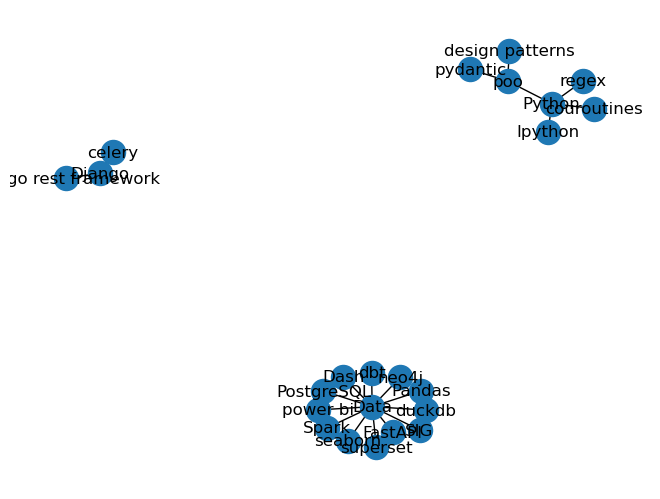

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

# Créer le graphe
G = nx.Graph()

for item in xm.getMaker('star-purple')[1:]:
    p = getparent(item['node'])
    if p:
        G.add_edge(item['title'], p)

# Positions des nœuds
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True)
plt.show()


### Remarque
En fait quand on construit un arrête entre sommet, si le sommet n'existe pas, le sommet est crée et représenté dans le graphe.
Il manque les éléments n'ayant pas de relations avec d'autres et que l'on veut voir quand même.


## Graph pyvis

In [33]:
from pyvis.network import Network

items = xm.getMaker('star-purple')[1:]

# Créer le graphe
G = nx.Graph()

# nodes
for item in items:
    G.add_node(item['title'])

# edge
for item in items:
    p = getparent(item['node'])
    if p:
        G.add_edge(item['title'], p)

# Positions des nœuds
pos = nx.spring_layout(G)

# Graphe interactif avec PyVis
net = Network(height="800px", width="100%", notebook=True)
net.from_nx(G)

# Affichage interactif
net.show("xmindToGraph.html")

xmindToGraph.html
